# Lab 05 — Kontrol Kualitas Data Berbasis Visi AI

**Modul 5 · Computer Vision — PT Astra Honda Motor Learning Center**

Notebook ini mendampingi **Materi 5** pada silabus: *kontrol kualitas data berbasis
visi AI*.

Empat lab sebelumnya membangun sistem yang bekerja **hari ini**. Lab ini menjawab
pertanyaan yang paling sering terlupakan: bagaimana memastikan sistem itu masih dapat
dipercaya **pada bulan keenam**?

| Bagian | Isi | Butir materi |
|---|---|---|
| 1 | Gerbang mutu 1 — saat perekaman | Gerbang mutu |
| 2 | Gerbang mutu 2 — saat ekstraksi | Gerbang mutu |
| 3 | Gerbang mutu 3 — sebelum pencatatan | Gerbang mutu |
| 4 | Enam dimensi mutu data | Dimensi mutu |
| 5 | Peta kendali performa mingguan | Pemantauan |
| 6 | Deteksi pergeseran (drift) dengan PSI | Pemantauan |
| 7 | Pemicu pelatihan ulang | Siklus perbaikan |
| 8 | Papan pantau mutu | Pemantauan |
| 9 | Latihan mandiri | — |

> **Catatan tentang data.** Bagian 1 memakai citra sungguhan yang dibuat notebook ini.
> Bagian 4–8 memakai **catatan operasional simulasi selama 16 minggu**, karena data
> produksi selama itu tentu tidak tersedia di ruang kelas. Polanya sengaja dibuat
> menyerupai kejadian nyata, tetapi angkanya bukan hasil pengukuran dan tidak boleh
> dikutip sebagai kinerja sistem AHM.

In [1]:
# --- Persiapan ------------------------------------------------------------
import os
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

np.random.seed(42)
KELUARAN = "keluaran_lab05"
os.makedirs(KELUARAN, exist_ok=True)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

MERAH, BIRU, HIJAU, KUNING, ABU = "#CE0E2D", "#00A8BE", "#2E8B57", "#E39A00", "#7C97A6"
print("siap")

siap


## 1. Gerbang mutu 1 — saat perekaman

Gerbang pertama adalah yang paling murah dan paling berdampak: **menolak citra buruk di
tempat, sebelum diunggah**. Petugas masih memegang dokumennya, sehingga memotret ulang
hanya butuh sepuluh detik. Bandingkan dengan menemukan masalah yang sama tiga hari
kemudian, ketika dokumennya sudah kembali ke vendor.

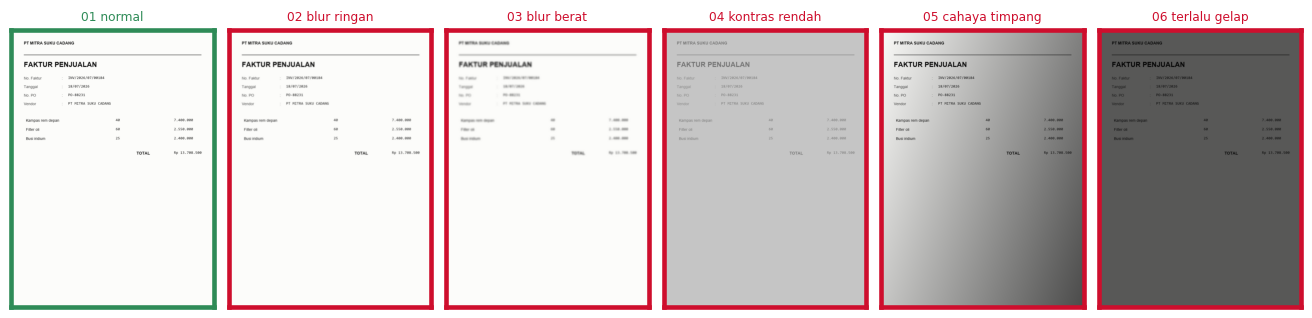

,unggahan,ketajaman,kontras,beda_cahaya,keputusan,alasan
0,01 normal,585.2,197.3,7.3,TERIMA,-
1,02 blur ringan,48.8,105.3,7.3,FOTO ULANG,kurang tajam
2,03 blur berat,1.6,65.8,7.3,FOTO ULANG,"kurang tajam, kontras rendah"
3,04 kontras rendah,67.1,66.8,2.5,FOTO ULANG,"kurang tajam, kontras rendah"
4,05 cahaya timpang,363.9,67.0,81.8,FOTO ULANG,"kontras rendah, cahaya timpang"
5,06 terlalu gelap,71.8,69.0,2.6,FOTO ULANG,"kurang tajam, kontras rendah"


In [2]:
JALUR_FONT = ["/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
              "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
              "/Library/Fonts/Arial.ttf", "C:/Windows/Fonts/arial.ttf"]
JALUR_FONT_TEBAL = ["/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
                    "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
                    "C:/Windows/Fonts/arialbd.ttf"]
JALUR_FONT_MONO = ["/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
                   "/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf",
                   "C:/Windows/Fonts/consola.ttf"]


def ambil_font(ukuran, tebal=False, mono=False):
    for jalur in (JALUR_FONT_MONO if mono else (JALUR_FONT_TEBAL if tebal else JALUR_FONT)):
        if os.path.exists(jalur):
            return ImageFont.truetype(jalur, ukuran)
    return ImageFont.load_default()


def buat_dokumen(no_faktur="INV/2026/07/00184", tanggal="18/07/2026"):
    L, T = 760, 1040
    kanvas = Image.new("RGB", (L, T), (252, 252, 250))
    gbr = ImageDraw.Draw(kanvas)
    gbr.text((48, 44), "PT MITRA SUKU CADANG", font=ambil_font(15, tebal=True), fill=(20, 20, 20))
    gbr.line([(48, 96), (L - 48, 96)], fill=(60, 60, 60), width=2)
    gbr.text((48, 118), "FAKTUR PENJUALAN", font=ambil_font(26, tebal=True), fill=(15, 15, 15))
    y = 176
    for label, nilai in (("No. Faktur", no_faktur), ("Tanggal", tanggal),
                         ("No. PO", "PO-88231"), ("Vendor", "PT MITRA SUKU CADANG")):
        gbr.text((48, y), label, font=ambil_font(14), fill=(70, 70, 70))
        gbr.text((190, y), ":", font=ambil_font(14), fill=(70, 70, 70))
        gbr.text((214, y), nilai, font=ambil_font(14, mono=True), fill=(15, 15, 15))
        y += 32
    y += 30
    for nama, qty, harga in (("Kampas rem depan", 40, 185000), ("Filter oli", 60, 42500),
                             ("Busi iridium", 25, 96000)):
        gbr.text((56, y), nama, font=ambil_font(14), fill=(25, 25, 25))
        gbr.text((392, y), str(qty), font=ambil_font(14, mono=True), fill=(25, 25, 25))
        gbr.text((610, y), f"{qty * harga:,}".replace(",", "."),
                 font=ambil_font(14, mono=True), fill=(25, 25, 25))
        y += 34
    gbr.text((470, y + 20), "TOTAL", font=ambil_font(15, tebal=True), fill=(25, 25, 25))
    gbr.text((610, y + 20), "Rp 13.708.500", font=ambil_font(14, tebal=True, mono=True),
             fill=(15, 15, 15))
    gbr.rectangle([(2, 2), (L - 3, T - 3)], outline=(215, 215, 215), width=2)
    return cv2.cvtColor(np.array(kanvas), cv2.COLOR_RGB2BGR)


def ukur_mutu(citra):
    abu = cv2.cvtColor(citra, cv2.COLOR_BGR2GRAY) if citra.ndim == 3 else citra
    halus = cv2.medianBlur(abu, 3)
    ambang = cv2.threshold(abu, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[0]
    tinta, kertas = abu[abu <= ambang], abu[abu > ambang]
    t, l = abu.shape
    kuadran = [abu[:t // 2, :l // 2], abu[:t // 2, l // 2:],
               abu[t // 2:, :l // 2], abu[t // 2:, l // 2:]]
    return {"ketajaman": float(cv2.Laplacian(halus, cv2.CV_64F).var()),
            "kontras": float(kertas.mean() - tinta.mean()) if tinta.size and kertas.size else 0.0,
            "beda_cahaya": float(max(np.mean(k) for k in kuadran) -
                                 min(np.mean(k) for k in kuadran))}


AMBANG_MUTU = {"ketajaman": 100.0, "kontras": 100.0, "beda_cahaya": 30.0}


def gerbang_1(citra):
    u = ukur_mutu(citra)
    alasan = []
    if u["ketajaman"] < AMBANG_MUTU["ketajaman"]:
        alasan.append("kurang tajam")
    if u["kontras"] < AMBANG_MUTU["kontras"]:
        alasan.append("kontras rendah")
    if u["beda_cahaya"] > AMBANG_MUTU["beda_cahaya"]:
        alasan.append("cahaya timpang")
    return (len(alasan) == 0), alasan, u


dokumen = buat_dokumen()
tinggi, lebar = dokumen.shape[:2]
yy, xx = np.mgrid[0:tinggi, 0:lebar]
gradien = (1.0 - 0.7 * ((xx / lebar) * 0.7 + (yy / tinggi) * 0.3))[:, :, None]

unggahan = {
    "01 normal": dokumen,
    "02 blur ringan": cv2.GaussianBlur(dokumen, (5, 5), 0),
    "03 blur berat": cv2.GaussianBlur(dokumen, (15, 15), 0),
    "04 kontras rendah": np.clip(dokumen * 0.34 + 112, 0, 255).astype(np.uint8),
    "05 cahaya timpang": np.clip(dokumen.astype(np.float32) * gradien, 0, 255).astype(np.uint8),
    "06 terlalu gelap": np.clip(dokumen.astype(np.float32) * 0.35, 0, 255).astype(np.uint8),
}

catatan_gerbang = []
for nama, citra in unggahan.items():
    lolos, alasan, ukuran = gerbang_1(citra)
    catatan_gerbang.append({"unggahan": nama, **{k: round(v, 1) for k, v in ukuran.items()},
                            "keputusan": "TERIMA" if lolos else "FOTO ULANG",
                            "alasan": ", ".join(alasan) or "-"})

fig, sumbu = plt.subplots(1, 6, figsize=(12, 3.4))
for ax, (nama, citra) in zip(sumbu, unggahan.items()):
    lolos, _, _ = gerbang_1(citra)
    ax.imshow(cv2.cvtColor(citra, cv2.COLOR_BGR2RGB))
    ax.set_title(nama, fontsize=8, color=HIJAU if lolos else MERAH)
    for sisi in ax.spines.values():
        sisi.set_edgecolor(HIJAU if lolos else MERAH)
        sisi.set_linewidth(3)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

pd.DataFrame(catatan_gerbang)

## 2. Gerbang mutu 2 — saat ekstraksi

Gerbang kedua bekerja pada **hasil baca**, bukan pada citra. Tiga pemeriksaan yang paling
berguna: kelengkapan field wajib, keyakinan minimum, dan kewajaran nilai.

In [3]:
FIELD_WAJIB = ["no_faktur", "tanggal", "no_po", "vendor", "total"]
AMBANG_KEYAKINAN = 0.85
BATAS_NILAI = (100_000, 5_000_000_000)   # rentang nominal yang dianggap wajar


def gerbang_2(catatan):
    alasan = []
    kosong = [f for f in FIELD_WAJIB if not catatan.get(f)]
    if kosong:
        alasan.append("field wajib kosong: " + ", ".join(kosong))
    keyakinan = catatan.get("conf_min", 0.0)
    if keyakinan < AMBANG_KEYAKINAN:
        alasan.append(f"keyakinan {keyakinan:.2f} di bawah ambang {AMBANG_KEYAKINAN}")
    total = catatan.get("total")
    if total is not None and not (BATAS_NILAI[0] <= total <= BATAS_NILAI[1]):
        alasan.append(f"nilai total {total:,} di luar rentang wajar")
    return (len(alasan) == 0), alasan


contoh_ekstraksi = [
    {"doc": "A", "no_faktur": "INV/2026/07/00184", "tanggal": "2026-07-18", "no_po": "PO-88231",
     "vendor": "PT MITRA SUKU CADANG", "total": 13_708_500, "conf_min": 0.94},
    {"doc": "B", "no_faktur": "INV/2026/07/00185", "tanggal": "2026-07-19", "no_po": "PO-88232",
     "vendor": "PT MITRA SUKU CADANG", "total": 9_120_000, "conf_min": 0.71},
    {"doc": "C", "no_faktur": "INV/2026/07/00186", "tanggal": None, "no_po": "PO-88233",
     "vendor": "PT SUMBER LOGAM PRIMA", "total": 8_400_000, "conf_min": 0.91},
    {"doc": "D", "no_faktur": "INV/2026/07/00187", "tanggal": "2026-07-20", "no_po": "PO-88234",
     "vendor": "PT MITRA SUKU CADANG", "total": 137_085_000_000, "conf_min": 0.90},
]

for c in contoh_ekstraksi:
    lolos, alasan = gerbang_2(c)
    print(f'{c["doc"]}: {"LANJUT" if lolos else "TAHAN "}  {"; ".join(alasan) or "semua pemeriksaan lolos"}')

A: LANJUT  semua pemeriksaan lolos
B: TAHAN   keyakinan 0.71 di bawah ambang 0.85
C: TAHAN   field wajib kosong: tanggal
D: TAHAN   nilai total 137,085,000,000 di luar rentang wajar


Dokumen **D** menunjukkan mengapa pemeriksaan kewajaran nilai penting: keyakinan OCR-nya
tinggi (0,90) dan seluruh field terisi, tetapi nominalnya seratus ribu kali lipat dari
yang masuk akal — kemungkinan besar pemisah ribuan terbaca sebagai digit tambahan.
**Keyakinan tinggi tidak sama dengan benar.**

## 3. Gerbang mutu 3 — sebelum pencatatan

Gerbang terakhir berdiri tepat sebelum data masuk sistem keuangan. Di sinilah
pemeriksaan yang membutuhkan konteks seluruh sistem dilakukan: duplikasi, kecocokan
data induk, dan kelengkapan berkas pendukung.

In [4]:
MASTER_PO = {"PO-88231": 13_708_500, "PO-88232": 9_120_000,
             "PO-88233": 8_400_000, "PO-88234": 6_012_870}
TOLERANSI = 0.02


def gerbang_3(catatan, sudah_masuk):
    alasan = []
    if catatan["no_faktur"] in sudah_masuk:
        alasan.append("nomor faktur sudah pernah dicatat")
    if catatan["no_po"] not in MASTER_PO:
        alasan.append("nomor PO tidak ada di data induk")
    else:
        selisih = abs(catatan["total"] - MASTER_PO[catatan["no_po"]]) / MASTER_PO[catatan["no_po"]]
        if selisih > TOLERANSI:
            alasan.append(f"selisih {selisih:.1%} terhadap nilai PO")
    if not catatan.get("ada_pengesahan", True):
        alasan.append("berkas pendukung/pengesahan belum lengkap")
    return (len(alasan) == 0), alasan


sudah_masuk = {"INV/2026/07/00180"}
uji_gerbang3 = [
    {"no_faktur": "INV/2026/07/00184", "no_po": "PO-88231", "total": 13_708_500, "ada_pengesahan": True},
    {"no_faktur": "INV/2026/07/00180", "no_po": "PO-88232", "total": 9_120_000, "ada_pengesahan": True},
    {"no_faktur": "INV/2026/07/00185", "no_po": "PO-77777", "total": 5_000_000, "ada_pengesahan": True},
    {"no_faktur": "INV/2026/07/00186", "no_po": "PO-88233", "total": 11_000_000, "ada_pengesahan": True},
    {"no_faktur": "INV/2026/07/00187", "no_po": "PO-88234", "total": 6_012_870, "ada_pengesahan": False},
]
for c in uji_gerbang3:
    lolos, alasan = gerbang_3(c, sudah_masuk)
    print(f'{c["no_faktur"]}: {"CATAT " if lolos else "TAHAN "} {"; ".join(alasan) or "aman untuk dicatat"}')
    if lolos:
        sudah_masuk.add(c["no_faktur"])

INV/2026/07/00184: CATAT  aman untuk dicatat
INV/2026/07/00180: TAHAN  nomor faktur sudah pernah dicatat
INV/2026/07/00185: TAHAN  nomor PO tidak ada di data induk
INV/2026/07/00186: TAHAN  selisih 31.0% terhadap nilai PO
INV/2026/07/00187: TAHAN  berkas pendukung/pengesahan belum lengkap


## 4. Enam dimensi mutu data

Kini kita naik dari satu dokumen ke **populasi dokumen**. Enam dimensi berikut adalah
kerangka baku dalam tata kelola data, dan masing-masing dapat dihitung dari catatan
audit yang sudah dibuat Lab 04.

Mulai bagian ini kita memakai catatan operasional simulasi 16 minggu.

In [5]:
# === Pembuatan catatan operasional simulasi ===============================
# Cerita yang ditanam ke dalam data:
#   minggu 1-8   : keadaan normal
#   minggu 9-12  : salah satu vendor mengubah format faktur -> keyakinan & akurasi turun
#   minggu 13-16 : model dilatih ulang -> performa pulih
MINGGU = 16
DOK_PER_MINGGU = 220
acak = np.random.default_rng(2026)

barisan = []
for minggu in range(1, MINGGU + 1):
    if minggu <= 8:
        conf_rerata, akurasi_dasar, porsi_format_baru = 0.93, 0.975, 0.0
    elif minggu <= 12:
        maju = (minggu - 8) / 4
        conf_rerata = 0.93 - 0.10 * maju
        akurasi_dasar = 0.975 - 0.09 * maju
        porsi_format_baru = 0.15 + 0.35 * maju
    else:
        conf_rerata, akurasi_dasar, porsi_format_baru = 0.925, 0.968, 0.5

    jumlah = int(acak.normal(DOK_PER_MINGGU, 18))
    for i in range(max(60, jumlah)):
        format_baru = acak.random() < porsi_format_baru
        conf = float(np.clip(acak.normal(conf_rerata - (0.05 if format_baru else 0), 0.05), 0.3, 0.999))
        benar = acak.random() < (akurasi_dasar - (0.05 if format_baru and minggu <= 12 else 0))
        barisan.append({
            "minggu": minggu,
            "doc_id": f"DOC-{minggu:02d}-{i:04d}",
            "vendor": "VENDOR_B" if format_baru else "VENDOR_A",
            "conf_min": round(conf, 3),
            "benar": bool(benar),
            "lengkap": bool(acak.random() < (0.995 if conf > 0.8 else 0.93)),
            "konsisten": bool(acak.random() < 0.985),
            "valid_format": bool(acak.random() < 0.99),
            "duplikat": bool(acak.random() < 0.006),
            "durasi_menit": float(np.clip(acak.gamma(2.0, 1.6) + (2.5 if conf < 0.85 else 0), 0.3, 60)),
        })

catatan = pd.DataFrame(barisan)
catatan.to_csv(os.path.join(KELUARAN, "catatan_operasional.csv"), index=False)
print(f"{len(catatan):,} catatan dokumen selama {MINGGU} minggu")
print(catatan.head().to_string(index=False))

3,579 catatan dokumen selama 16 minggu
 minggu      doc_id   vendor  conf_min  benar  lengkap  konsisten  valid_format  duplikat  durasi_menit
      1 DOC-01-0000 VENDOR_A     0.835   True     True       True          True     False      4.651119
      1 DOC-01-0001 VENDOR_A     0.956   True     True       True          True     False      3.967027
      1 DOC-01-0002 VENDOR_A     0.906   True     True       True          True     False      1.448133
      1 DOC-01-0003 VENDOR_A     0.939   True     True       True          True     False      5.774669
      1 DOC-01-0004 VENDOR_A     0.904   True     True       True          True     False      1.298735


        dimensi                   pertanyaan  target_%  minggu 1-8 (%)  minggu 9-12 (%) status minggu 9-12
        Akurasi Nilai sesuai dokumen sumber?      97.0           97.51            90.91    DI BAWAH TARGET
    Kelengkapan    Semua field wajib terisi?      99.0           99.66            98.12    DI BAWAH TARGET
    Konsistensi   Selaras dengan data induk?      98.0           98.36            98.85    memenuhi target
       Keunikan         Bebas catatan ganda?      99.5           99.77            99.48    DI BAWAH TARGET
Ketepatan waktu      Selesai dalam 15 menit?      95.0           99.77            99.69    memenuhi target
      Validitas      Sesuai format & aturan?      99.0           98.92            98.96    DI BAWAH TARGET


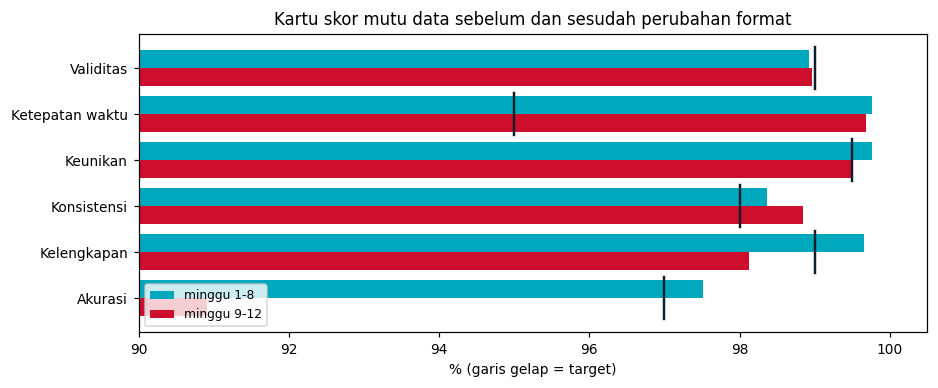

In [6]:
SLA_MENIT = 15


def kartu_skor_mutu(df):
    n = len(df)
    return pd.DataFrame([
        {"dimensi": "Akurasi", "pertanyaan": "Nilai sesuai dokumen sumber?",
         "nilai_%": round(100 * df["benar"].mean(), 2), "target_%": 97.0},
        {"dimensi": "Kelengkapan", "pertanyaan": "Semua field wajib terisi?",
         "nilai_%": round(100 * df["lengkap"].mean(), 2), "target_%": 99.0},
        {"dimensi": "Konsistensi", "pertanyaan": "Selaras dengan data induk?",
         "nilai_%": round(100 * df["konsisten"].mean(), 2), "target_%": 98.0},
        {"dimensi": "Keunikan", "pertanyaan": "Bebas catatan ganda?",
         "nilai_%": round(100 * (1 - df["duplikat"].mean()), 2), "target_%": 99.5},
        {"dimensi": "Ketepatan waktu", "pertanyaan": f"Selesai dalam {SLA_MENIT} menit?",
         "nilai_%": round(100 * (df["durasi_menit"] <= SLA_MENIT).mean(), 2), "target_%": 95.0},
        {"dimensi": "Validitas", "pertanyaan": "Sesuai format & aturan?",
         "nilai_%": round(100 * df["valid_format"].mean(), 2), "target_%": 99.0},
    ])


kartu_awal = kartu_skor_mutu(catatan[catatan["minggu"] <= 8])
kartu_krisis = kartu_skor_mutu(catatan[catatan["minggu"].between(9, 12)])

gabung = kartu_awal[["dimensi", "pertanyaan", "target_%"]].copy()
gabung["minggu 1-8 (%)"] = kartu_awal["nilai_%"]
gabung["minggu 9-12 (%)"] = kartu_krisis["nilai_%"]
gabung["status minggu 9-12"] = np.where(
    kartu_krisis["nilai_%"] >= kartu_awal["target_%"], "memenuhi target", "DI BAWAH TARGET")
print(gabung.to_string(index=False))

posisi = np.arange(len(kartu_awal))
fig, ax = plt.subplots(figsize=(8.6, 3.6))
ax.barh(posisi + 0.2, kartu_awal["nilai_%"], 0.4, label="minggu 1-8", color=BIRU)
ax.barh(posisi - 0.2, kartu_krisis["nilai_%"], 0.4, label="minggu 9-12", color=MERAH)
for i, target in enumerate(kartu_awal["target_%"]):
    ax.plot([target, target], [i - 0.45, i + 0.45], color="#0F1E2B", linewidth=1.6)
ax.set_yticks(posisi, kartu_awal["dimensi"])
ax.set_xlim(90, 100.5)
ax.set_xlabel("% (garis gelap = target)")
ax.set_title("Kartu skor mutu data sebelum dan sesudah perubahan format")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

Perhatikan bahwa hanya **akurasi** dan **ketepatan waktu** yang jatuh. Kelengkapan,
konsistensi, dan validitas tetap tinggi — karena aturan format tetap terpenuhi meski
isinya salah baca.

Ini pelajaran penting: **memantau kelengkapan saja tidak akan pernah menangkap penurunan
akurasi.** Data bisa 100% lengkap dan 100% valid formatnya, tetapi tetap salah.

## 5. Peta kendali performa mingguan

Peta kendali (*control chart*) berasal dari pengendalian mutu manufaktur — konteks yang
sudah sangat akrab di lingkungan AHM. Prinsipnya sama persis: tetapkan garis tengah dan
batas kendali dari **periode acuan yang stabil**, lalu periksa apakah pengamatan baru
masih berada di dalam batas.

Batas dihitung dari data periode acuan (minggu 1–8), **bukan** dari seluruh data.
Jika seluruh data dipakai, periode bermasalah ikut melebarkan batas dan justru
menyamarkan masalahnya sendiri.

garis tengah      : 97.51%
sigma (minggu 1-8): 0.81%
batas kendali     : 95.08% .. 99.94%


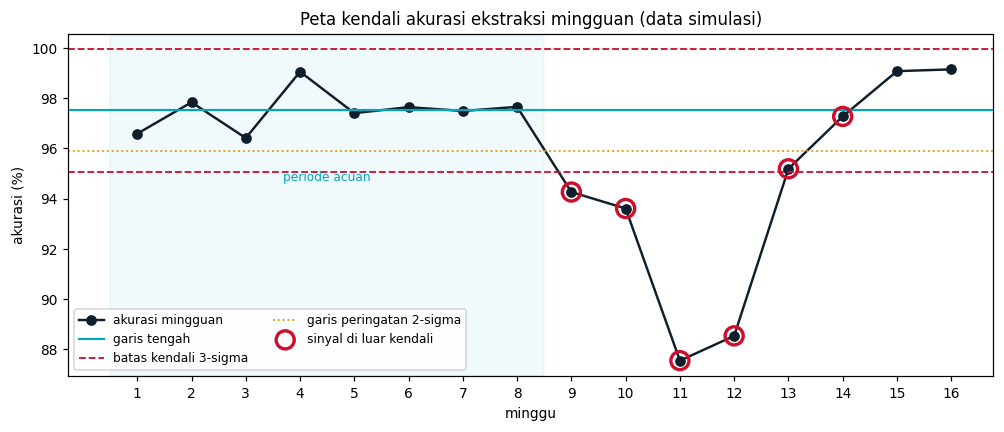

 minggu  jumlah  akurasi_%                                                                   sinyal
      1     205      96.59                                                                         
      2     231      97.84                                                                         
      3     223      96.41                                                                         
      4     211      99.05                                                                         
      5     231      97.40                                                                         
      6     212      97.64                                                                         
      7     239      97.49                                                                         
      8     213      97.65                                                                         
      9     244      94.26                                            di luar batas kendali 3-sigma


In [7]:
mingguan = catatan.groupby("minggu").agg(
    jumlah=("doc_id", "count"),
    akurasi=("benar", "mean"),
    conf_rerata=("conf_min", "mean"),
    tepat_waktu=("durasi_menit", lambda s: (s <= SLA_MENIT).mean()),
).reset_index()
mingguan["akurasi_%"] = (100 * mingguan["akurasi"]).round(2)

ACUAN = mingguan[mingguan["minggu"] <= 8]["akurasi"]
garis_tengah = float(ACUAN.mean())
sigma = float(ACUAN.std(ddof=1))
BKA, BKB = garis_tengah + 3 * sigma, garis_tengah - 3 * sigma
peringatan_bawah = garis_tengah - 2 * sigma

print(f"garis tengah      : {100 * garis_tengah:.2f}%")
print(f"sigma (minggu 1-8): {100 * sigma:.2f}%")
print(f"batas kendali     : {100 * BKB:.2f}% .. {100 * BKA:.2f}%")


def periksa_kendali(nilai, tengah, sigma_):
    # Dua aturan sederhana ala Western Electric
    bka, bkb = tengah + 3 * sigma_, tengah - 3 * sigma_
    peringatan = tengah - 2 * sigma_
    penanda = []
    for i, x in enumerate(nilai):
        alasan = []
        if x < bkb or x > bka:
            alasan.append("di luar batas kendali 3-sigma")
        jendela = nilai[max(0, i - 2):i + 1]
        if len(jendela) == 3 and sum(v < peringatan for v in jendela) >= 2:
            alasan.append("2 dari 3 titik berurutan di bawah 2-sigma")
        penanda.append("; ".join(alasan))
    return penanda


mingguan["sinyal"] = periksa_kendali(list(mingguan["akurasi"]), garis_tengah, sigma)
mingguan["terkendali"] = mingguan["sinyal"] == ""

fig, ax = plt.subplots(figsize=(9.2, 4))
ax.plot(mingguan["minggu"], 100 * mingguan["akurasi"], marker="o", color="#0F1E2B",
        linewidth=1.6, label="akurasi mingguan")
ax.axhline(100 * garis_tengah, color=BIRU, linewidth=1.4, label="garis tengah")
ax.axhline(100 * BKA, color=MERAH, linestyle="--", linewidth=1.2, label="batas kendali 3-sigma")
ax.axhline(100 * BKB, color=MERAH, linestyle="--", linewidth=1.2)
ax.axhline(100 * peringatan_bawah, color=KUNING, linestyle=":", linewidth=1.2,
           label="garis peringatan 2-sigma")
diluar = mingguan[~mingguan["terkendali"]]
ax.scatter(diluar["minggu"], 100 * diluar["akurasi"], s=140, facecolors="none",
           edgecolors=MERAH, linewidths=2.2, label="sinyal di luar kendali", zorder=5)
ax.axvspan(0.5, 8.5, color=BIRU, alpha=0.06)
ax.text(4.5, 100 * BKB - 0.35, "periode acuan", ha="center", color=BIRU, fontsize=8)
ax.set_xlabel("minggu")
ax.set_ylabel("akurasi (%)")
ax.set_title("Peta kendali akurasi ekstraksi mingguan (data simulasi)")
ax.set_xticks(mingguan["minggu"])
ax.legend(fontsize=8, loc="lower left", ncol=2)
plt.tight_layout()
plt.show()

print(mingguan[["minggu", "jumlah", "akurasi_%", "sinyal"]].to_string(index=False))

Peta kendali menjawab pertanyaan yang selalu muncul di rapat: **"apakah penurunan ini
wajar atau tidak?"** Fluktuasi kecil di dalam batas adalah keragaman biasa dan tidak
perlu ditindaklanjuti. Titik yang menembus batas barulah sinyal yang menuntut tindakan.

Tanpa batas kendali, tim cenderung bereaksi berlebihan terhadap turunnya angka satu
minggu, sekaligus mengabaikan penurunan perlahan yang justru berbahaya.

## 6. Deteksi pergeseran dengan PSI

Peta kendali membutuhkan **label kebenaran** untuk menghitung akurasi, dan label itu
mahal karena harus diperiksa manusia. Padahal pergeseran sering dapat dideteksi lebih
awal **tanpa label sama sekali**, cukup dengan mengamati perubahan sebaran skor
keyakinan.

*Population Stability Index* (PSI) membandingkan sebaran periode acuan dengan periode
berjalan:

$$\text{PSI} = \sum_i (p_i^{kini} - p_i^{acuan}) \cdot \ln \frac{p_i^{kini}}{p_i^{acuan}}$$

Pembacaan yang lazim dipakai:

| PSI | Arti | Tindakan |
|---|---|---|
| < 0,10 | sebaran stabil | pantau seperti biasa |
| 0,10 – 0,25 | mulai bergeser | selidiki penyebabnya |
| > 0,25 | pergeseran nyata | siapkan pelatihan ulang |

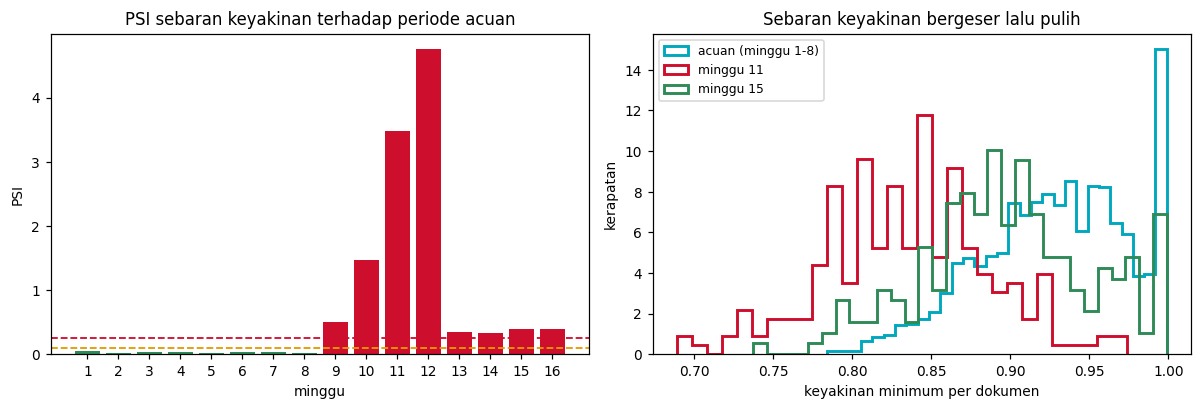

 minggu    psi             arti
      1 0.0555           stabil
      2 0.0201           stabil
      3 0.0388           stabil
      4 0.0273           stabil
      5 0.0126           stabil
      6 0.0410           stabil
      7 0.0271           stabil
      8 0.0160           stabil
      9 0.4951 pergeseran nyata
     10 1.4636 pergeseran nyata
     11 3.4818 pergeseran nyata
     12 4.7560 pergeseran nyata
     13 0.3450 pergeseran nyata
     14 0.3278 pergeseran nyata
     15 0.3906 pergeseran nyata
     16 0.3935 pergeseran nyata


In [8]:
def psi(acuan, kini, jumlah_bin=10):
    tepi = np.unique(np.quantile(acuan, np.linspace(0, 1, jumlah_bin + 1)))
    if len(tepi) < 3:
        return 0.0
    tepi[0], tepi[-1] = -np.inf, np.inf
    p_acuan = np.histogram(acuan, tepi)[0] / len(acuan)
    p_kini = np.histogram(kini, tepi)[0] / len(kini)
    p_acuan = np.clip(p_acuan, 1e-4, None)
    p_kini = np.clip(p_kini, 1e-4, None)
    return float(np.sum((p_kini - p_acuan) * np.log(p_kini / p_acuan)))


conf_acuan = catatan[catatan["minggu"] <= 8]["conf_min"].to_numpy()
nilai_psi = []
for minggu in range(1, MINGGU + 1):
    conf_kini = catatan[catatan["minggu"] == minggu]["conf_min"].to_numpy()
    nilai_psi.append({"minggu": minggu, "psi": round(psi(conf_acuan, conf_kini), 4)})
tabel_psi = pd.DataFrame(nilai_psi)
tabel_psi["arti"] = pd.cut(tabel_psi["psi"], [-0.01, 0.10, 0.25, np.inf],
                           labels=["stabil", "mulai bergeser", "pergeseran nyata"])

fig, (kiri, kanan) = plt.subplots(1, 2, figsize=(11, 3.8))
warna_psi = [HIJAU if v < 0.1 else (KUNING if v < 0.25 else MERAH) for v in tabel_psi["psi"]]
kiri.bar(tabel_psi["minggu"], tabel_psi["psi"], color=warna_psi)
kiri.axhline(0.10, color=KUNING, linestyle="--", linewidth=1.2)
kiri.axhline(0.25, color=MERAH, linestyle="--", linewidth=1.2)
kiri.set_xlabel("minggu"); kiri.set_ylabel("PSI")
kiri.set_title("PSI sebaran keyakinan terhadap periode acuan")
kiri.set_xticks(tabel_psi["minggu"])

for label, minggu_pilih, warna in (("acuan (minggu 1-8)", [1, 8], BIRU),
                                   ("minggu 11", [11, 11], MERAH),
                                   ("minggu 15", [15, 15], HIJAU)):
    bagian = catatan[catatan["minggu"].between(*minggu_pilih)]["conf_min"]
    kanan.hist(bagian, bins=30, density=True, histtype="step", linewidth=1.9,
               color=warna, label=label)
kanan.set_xlabel("keyakinan minimum per dokumen")
kanan.set_ylabel("kerapatan")
kanan.set_title("Sebaran keyakinan bergeser lalu pulih")
kanan.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(tabel_psi.to_string(index=False))

Bandingkan waktunya: PSI sudah memberi sinyal pada minggu 9–10, sementara peta kendali
akurasi baru meyakinkan beberapa minggu kemudian. Karena PSI **tidak memerlukan label**,
ia bisa dihitung setiap hari secara otomatis.

Praktik yang baik menggunakan keduanya: PSI sebagai **peringatan dini**, peta kendali
akurasi sebagai **konfirmasi berbasis bukti**.

Ada satu hal yang perlu dijelaskan dari tabel di atas: **PSI tetap tinggi (sekitar 0,35–0,40)
pada minggu 13–16, padahal akurasi sudah pulih.** Ini bukan kesalahan perhitungan.

Populasinya memang berubah secara permanen — separuh dokumen kini datang dalam format
baru VENDOR_B. Sebaran keyakinan hari ini memang tidak akan pernah sama lagi dengan
sebaran minggu 1–8, dan seharusnya memang tidak. Yang perlu dilakukan adalah
**menetapkan periode acuan baru** setelah model dilatih ulang dan divalidasi.

Tanpa penetapan acuan baru, sistem peringatan akan menyala terus-menerus, dan dalam
beberapa minggu tim akan berhenti mempercayainya. Kelelahan alarm adalah cara paling
umum sebuah sistem pemantauan menjadi tidak berguna.

In [9]:
# Menetapkan acuan baru: minggu 13-14 (setelah pelatihan ulang, sebelum dinilai lagi)
conf_acuan_baru = catatan[catatan["minggu"].between(13, 14)]["conf_min"].to_numpy()

banding = []
for minggu in range(9, MINGGU + 1):
    conf_kini = catatan[catatan["minggu"] == minggu]["conf_min"].to_numpy()
    banding.append({"minggu": minggu,
                    "psi_acuan_lama": round(psi(conf_acuan, conf_kini), 3),
                    "psi_acuan_baru": round(psi(conf_acuan_baru, conf_kini), 3)})
tabel_banding = pd.DataFrame(banding)
tabel_banding["arti_acuan_baru"] = pd.cut(tabel_banding["psi_acuan_baru"],
                                          [-0.01, 0.10, 0.25, np.inf],
                                          labels=["stabil", "mulai bergeser", "pergeseran nyata"])
print(tabel_banding.to_string(index=False))
print("\nDengan acuan baru, minggu 15-16 kembali terbaca stabil - persis seperti keadaan")
print("sesungguhnya. Penetapan ulang acuan wajib dicatat: kapan, oleh siapa, dan mengapa.")

 minggu  psi_acuan_lama  psi_acuan_baru  arti_acuan_baru
      9           0.495           0.042           stabil
     10           1.464           0.516 pergeseran nyata
     11           3.482           1.531 pergeseran nyata
     12           4.756           2.867 pergeseran nyata
     13           0.345           0.022           stabil
     14           0.328           0.018           stabil
     15           0.391           0.080           stabil
     16           0.393           0.035           stabil

Dengan acuan baru, minggu 15-16 kembali terbaca stabil - persis seperti keadaan
sesungguhnya. Penetapan ulang acuan wajib dicatat: kapan, oleh siapa, dan mengapa.


## 7. Pemicu pelatihan ulang

Sinyal tanpa aturan tindakan hanya menjadi grafik hiasan. Kesepakatan berikut sebaiknya
dibuat tertulis bersama pemilik proses, lengkap dengan penanggung jawabnya.

In [10]:
def putuskan_tindakan(baris_kendali, nilai_psi_minggu, porsi_tinjau):
    tindakan, alasan = "lanjut normal", []
    if nilai_psi_minggu > 0.25:
        alasan.append(f"PSI {nilai_psi_minggu:.2f} menunjukkan pergeseran nyata")
    elif nilai_psi_minggu > 0.10:
        alasan.append(f"PSI {nilai_psi_minggu:.2f} mulai bergeser")
    if baris_kendali["sinyal"]:
        alasan.append("peta kendali: " + baris_kendali["sinyal"])
    if porsi_tinjau > 0.30:
        alasan.append(f"beban tinjauan manusia {porsi_tinjau:.0%} melewati batas 30%")

    berat = sum([nilai_psi_minggu > 0.25, bool(baris_kendali["sinyal"]), porsi_tinjau > 0.30])
    if berat >= 2:
        tindakan = "LATIH ULANG - kumpulkan & labeli kasus gagal minggu ini"
    elif berat == 1:
        tindakan = "SELIDIKI - periksa sampel 50 dokumen berkeyakinan terendah"
    return tindakan, alasan


beban_tinjau = catatan.assign(perlu_tinjau=catatan["conf_min"] < AMBANG_KEYAKINAN) \
                      .groupby("minggu")["perlu_tinjau"].mean()

keputusan = []
for _, baris in mingguan.iterrows():
    minggu = int(baris["minggu"])
    tindakan, alasan = putuskan_tindakan(baris, float(tabel_psi.loc[minggu - 1, "psi"]),
                                         float(beban_tinjau[minggu]))
    keputusan.append({"minggu": minggu, "akurasi_%": baris["akurasi_%"],
                      "psi": tabel_psi.loc[minggu - 1, "psi"],
                      "beban_tinjau_%": round(100 * beban_tinjau[minggu], 1),
                      "tindakan": tindakan, "alasan": "; ".join(alasan) or "-"})

tabel_keputusan = pd.DataFrame(keputusan)
print(tabel_keputusan.to_string(index=False))

 minggu  akurasi_%    psi  beban_tinjau_%                                                   tindakan                                                                                                                                                                       alasan
      1      96.59 0.0555             4.9                                              lanjut normal                                                                                                                                                                            -
      2      97.84 0.0201             4.3                                              lanjut normal                                                                                                                                                                            -
      3      96.41 0.0388             6.3                                              lanjut normal                                                                              

Perhatikan bahwa pemicu pelatihan ulang **menuntut lebih dari satu sinyal**. Satu sinyal
saja cukup untuk menyelidiki, tetapi belum cukup untuk menjalankan pelatihan ulang yang
mahal. Susunan ini menghindari dua kesalahan yang sama merugikannya: bereaksi berlebihan
pada keragaman biasa, dan menunda tindakan sampai keluhan datang dari pengguna.

## 8. Papan pantau mutu

Empat panel yang cukup untuk rapat mingguan pemilik proses.

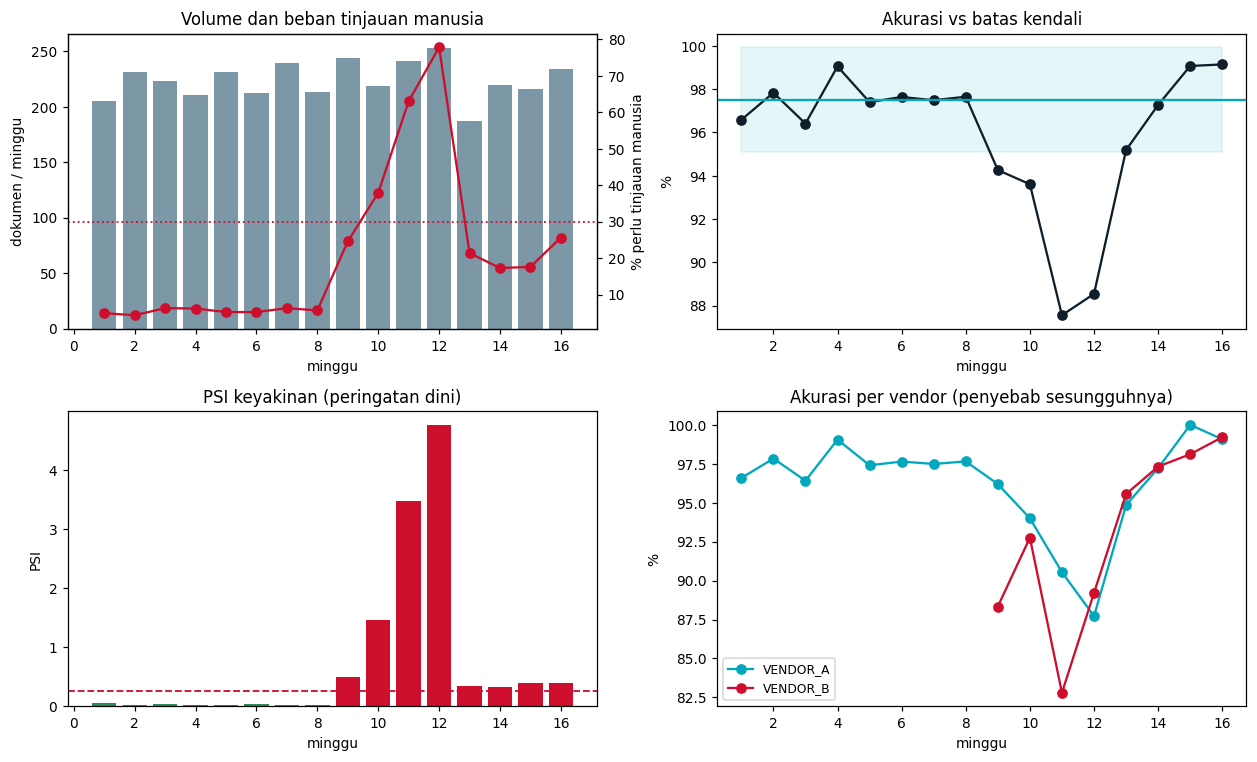

Papan pantau disimpan ke e:\Paket_Latihan_ML_AHM\Modul 5\keluaran_lab05\papan_pantau_mutu.png


In [11]:
fig, sumbu = plt.subplots(2, 2, figsize=(11.5, 7))

# Panel 1: volume dan beban tinjauan
kiri_atas = sumbu[0, 0]
kiri_atas.bar(mingguan["minggu"], mingguan["jumlah"], color=ABU, label="volume dokumen")
kiri_atas.set_ylabel("dokumen / minggu")
kembar = kiri_atas.twinx()
kembar.plot(mingguan["minggu"], 100 * beban_tinjau.values, marker="o", color=MERAH,
            label="beban tinjauan (%)")
kembar.axhline(30, color=MERAH, linestyle=":", linewidth=1.2)
kembar.set_ylabel("% perlu tinjauan manusia")
kiri_atas.set_title("Volume dan beban tinjauan manusia")
kiri_atas.set_xlabel("minggu")

# Panel 2: akurasi dengan batas kendali
kanan_atas = sumbu[0, 1]
kanan_atas.plot(mingguan["minggu"], 100 * mingguan["akurasi"], marker="o", color="#0F1E2B")
kanan_atas.axhline(100 * garis_tengah, color=BIRU)
kanan_atas.fill_between(mingguan["minggu"], 100 * BKB, 100 * BKA, color=BIRU, alpha=0.10)
kanan_atas.set_title("Akurasi vs batas kendali")
kanan_atas.set_xlabel("minggu"); kanan_atas.set_ylabel("%")

# Panel 3: PSI
kiri_bawah = sumbu[1, 0]
kiri_bawah.bar(tabel_psi["minggu"], tabel_psi["psi"], color=warna_psi)
kiri_bawah.axhline(0.25, color=MERAH, linestyle="--", linewidth=1.2)
kiri_bawah.set_title("PSI keyakinan (peringatan dini)")
kiri_bawah.set_xlabel("minggu"); kiri_bawah.set_ylabel("PSI")

# Panel 4: akurasi per vendor - membuka penyebab sesungguhnya
kanan_bawah = sumbu[1, 1]
per_vendor = catatan.groupby(["minggu", "vendor"])["benar"].mean().unstack()
for vendor, warna in (("VENDOR_A", BIRU), ("VENDOR_B", MERAH)):
    if vendor in per_vendor:
        kanan_bawah.plot(per_vendor.index, 100 * per_vendor[vendor], marker="o",
                         color=warna, label=vendor)
kanan_bawah.set_title("Akurasi per vendor (penyebab sesungguhnya)")
kanan_bawah.set_xlabel("minggu"); kanan_bawah.set_ylabel("%")
kanan_bawah.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(KELUARAN, "papan_pantau_mutu.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Papan pantau disimpan ke", os.path.abspath(os.path.join(KELUARAN, "papan_pantau_mutu.png")))

Panel keempat adalah yang paling berharga. Angka agregat hanya memberi tahu **bahwa**
ada masalah; pemecahan per kelompok memberi tahu **di mana** masalahnya. Di sini terlihat
jelas bahwa akurasi VENDOR_A tidak pernah bergerak — seluruh penurunan berasal dari
dokumen VENDOR_B yang berganti format.

Kesimpulan tindakannya pun berubah total: yang dibutuhkan bukan mengganti model untuk
semua dokumen, melainkan menambahkan contoh format baru VENDOR_B ke data latih, atau
sekadar menyesuaikan pola ekstraksi untuk vendor tersebut.

**Selalu pecah metrik mutu menurut sumber, vendor, jenis dokumen, dan perangkat.**

## 9. Latihan mandiri

1. **Ambang gerbang.** Turunkan `AMBANG_MUTU["ketajaman"]` menjadi 20. Unggahan mana yang
   kini lolos gerbang 1? Bagaimana dampaknya terhadap akurasi di hilir?
2. **Periode acuan.** Hitung ulang batas kendali memakai seluruh 16 minggu sebagai acuan.
   Apakah sinyal minggu 11 masih terdeteksi? Jelaskan mengapa memilih periode acuan yang
   stabil itu penting.
3. **PSI pada besaran lain.** Hitung PSI untuk `durasi_menit`, bukan `conf_min`. Apakah
   pergeserannya terdeteksi pada minggu yang sama?
4. **Aturan Western Electric.** Tambahkan aturan ketiga pada `periksa_kendali`: delapan
   titik berurutan berada di sisi yang sama dari garis tengah. Minggu mana yang tertangkap?
5. **Rancangan tata kelola.** Untuk satu proses di unit kerja Anda, tuliskan: siapa
   pemilik metrik, seberapa sering ditinjau, ambang mana yang memicu penyelidikan, dan
   siapa yang berwenang memutuskan pelatihan ulang. Ini keluaran paling berharga dari
   modul ini.

In [12]:
# Kerangka jawaban latihan 4 - silakan lengkapi
def aturan_delapan_titik(nilai, tengah):
    penanda = [""] * len(nilai)
    # TODO: tandai indeks ke-i bila nilai[i-7:i+1] seluruhnya berada di satu sisi
    #       terhadap garis tengah (semua di atas, atau semua di bawah)
    return penanda


hasil_latihan = aturan_delapan_titik(list(mingguan["akurasi"]), garis_tengah)
print("minggu yang tertangkap:",
      [i + 1 for i, tanda in enumerate(hasil_latihan) if tanda] or "belum ada (fungsi belum diisi)")

minggu yang tertangkap: belum ada (fungsi belum diisi)


## Ringkasan

- Mutu dijaga lewat **tiga gerbang**: saat perekaman, saat ekstraksi, dan sebelum
  pencatatan. Gerbang paling murah adalah yang paling awal.
- **Keyakinan tinggi tidak sama dengan benar.** Pemeriksaan kewajaran nilai menangkap
  kesalahan yang lolos dari skor keyakinan.
- Enam dimensi mutu data harus dipantau bersama. Memantau kelengkapan saja tidak akan
  pernah menangkap penurunan akurasi.
- **Peta kendali** memisahkan keragaman biasa dari masalah sungguhan, dan batasnya harus
  dihitung dari periode acuan yang stabil.
- **PSI** memberi peringatan dini tanpa memerlukan label, sehingga dapat berjalan otomatis
  setiap hari. Pakai keduanya: PSI untuk peringatan, akurasi berlabel untuk konfirmasi.
- Setelah perubahan permanen dan pelatihan ulang, **periode acuan harus ditetapkan ulang**.
  Acuan yang usang membuat alarm menyala terus sampai tidak ada lagi yang mempercayainya.
- Pemicu pelatihan ulang sebaiknya **menuntut lebih dari satu sinyal**, dan disepakati
  tertulis bersama pemilik proses.
- **Pecah setiap metrik menurut vendor, sumber, dan jenis dokumen.** Angka agregat
  menyembunyikan penyebab.

---

Ini notebook terakhir dari rangkaian Modul 5. Langkah berikutnya bukan lagi coding:
pilih satu dokumen di unit kerja Anda, ukur keadaan sekarang, lalu bicarakan hasilnya
dengan pemilik prosesnya.